<a href="https://colab.research.google.com/github/narsimha1603/Major-Project/blob/main/TMD1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning, module='jupyter_client')
print("Deprecation warnings from 'jupyter_client' will now be suppressed.")

Deprecation warnings from 'jupyter_client' will now be suppressed.


In [6]:
data = pd.read_csv(
    "dengue_dataset_5000_cases.csv",
    parse_dates=['Date']
).set_index('Date')

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


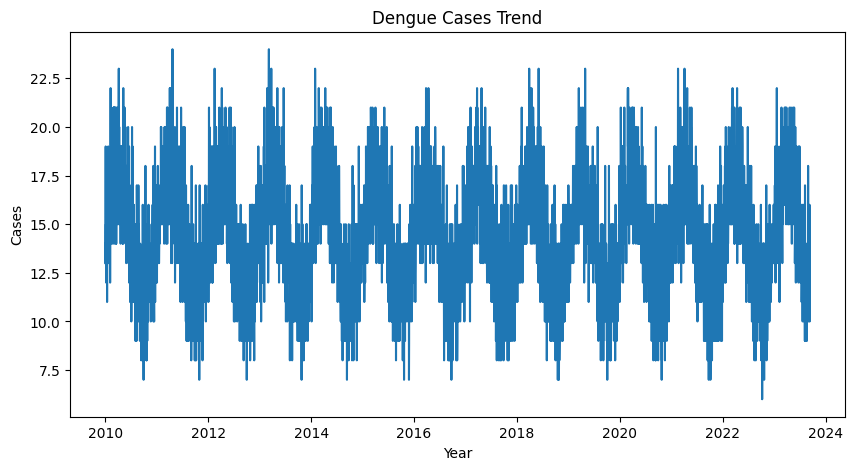

In [7]:
plt.figure(figsize=(10,5))
plt.plot(data.index, data['Dengue_Cases'])
plt.title("Dengue Cases Trend")
plt.xlabel("Year")
plt.ylabel("Cases")
plt.show()

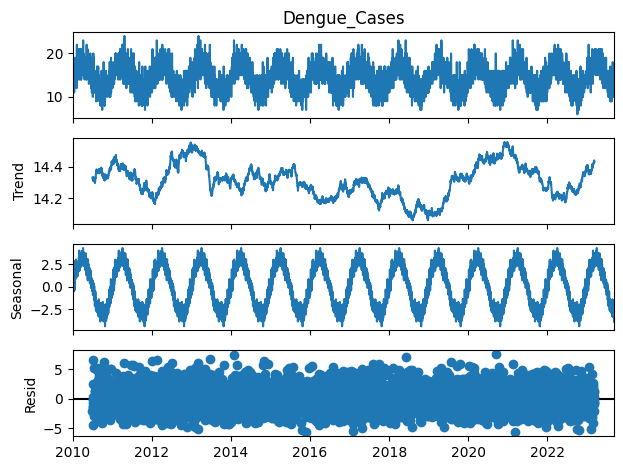

In [8]:
decomposition = seasonal_decompose(data['Dengue_Cases'], model='additive', period=365)

decomposition.plot()
plt.show()

In [10]:
data = data.ffill()

In [11]:
scaler = MinMaxScaler()

data[['Temperature (°C)','Rainfall (mm)','Humidity (%)']] = scaler.fit_transform(
    data[['Temperature (°C)','Rainfall (mm)','Humidity (%)']]
)

In [12]:
result = adfuller(data['Dengue_Cases'])
print("ADF p-value:", result[1])

ADF p-value: 0.0008686016565226949


In [13]:
arm_data = data.copy()

arm_data['High_Temp'] = arm_data['Temperature (°C)'] > arm_data['Temperature (°C)'].mean()
arm_data['High_Rain'] = arm_data['Rainfall (mm)'] > arm_data['Rainfall (mm)'].mean()
arm_data['High_Humidity'] = arm_data['Humidity (%)'] > arm_data['Humidity (%)'].mean()
arm_data['High_Cases'] = arm_data['Dengue_Cases'] > arm_data['Dengue_Cases'].mean()

arm_df = arm_data[['High_Temp','High_Rain','High_Humidity','High_Cases']]

frequent = apriori(arm_df, min_support=0.3, use_colnames=True)

rules = association_rules(frequent, metric="confidence", min_threshold=0.6)

print("\nAssociation Rules")
print(rules[['antecedents','consequents','support','confidence']])


Association Rules
                               antecedents  \
0                              (High_Temp)   
1                              (High_Rain)   
2                              (High_Temp)   
3                          (High_Humidity)   
4                              (High_Temp)   
5                             (High_Cases)   
6                          (High_Humidity)   
7                              (High_Rain)   
8                              (High_Rain)   
9                             (High_Cases)   
10                         (High_Humidity)   
11                            (High_Cases)   
12              (High_Temp, High_Humidity)   
13                  (High_Temp, High_Rain)   
14              (High_Humidity, High_Rain)   
15                             (High_Temp)   
16                         (High_Humidity)   
17                             (High_Rain)   
18                  (High_Temp, High_Rain)   
19                 (High_Temp, High_Cases)   
20             

In [16]:
# Use last 5000 records for training and set frequency to Daily
y = data['Dengue_Cases'].tail(5000).asfreq('D')

model = ARIMA(y, order=(1,1,1))

# Removed invalid 'method' and 'maxiter' arguments
model_fit = model.fit()

print("\nARIMA Model Built Successfully")


ARIMA Model Built Successfully


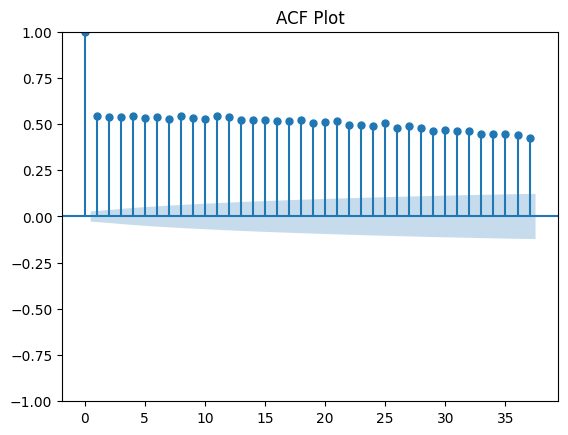

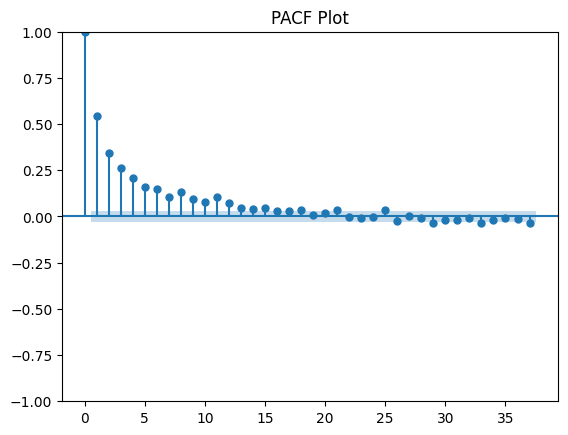

In [17]:
plot_acf(y)
plt.title("ACF Plot")
plt.show()

plot_pacf(y)
plt.title("PACF Plot")
plt.show()

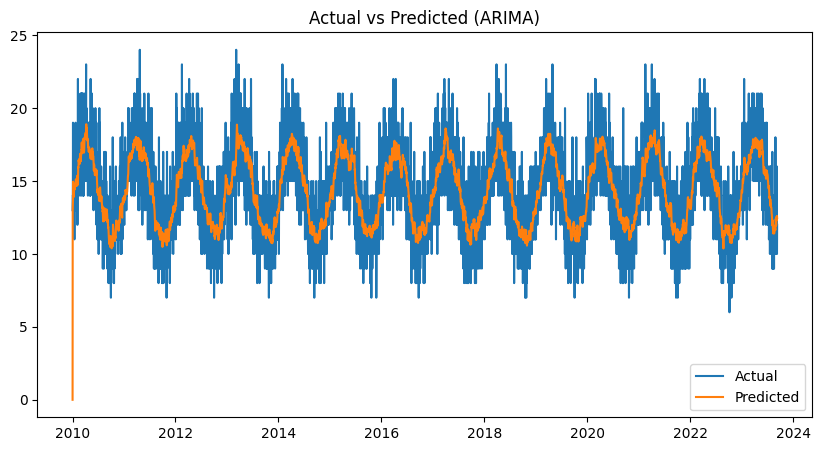

In [18]:
predicted = model_fit.predict(start=y.index[0], end=y.index[-1])

plt.figure(figsize=(10,5))
plt.plot(y.index, y, label="Actual")
plt.plot(y.index, predicted, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted (ARIMA)")
plt.show()

In [19]:
rmse = np.sqrt(mean_squared_error(y, predicted))
mae = mean_absolute_error(y, predicted)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 2.1456684189942234
MAE: 1.7118821443557357


In [20]:
steps = 24   # 2 years (monthly)

forecast = model_fit.forecast(steps=steps)

future_dates = pd.date_range(start="2026-01-01", periods=steps, freq='M')

forecast_series = pd.Series(forecast.values, index=future_dates)

print("\nForecast for 2026–2027")
print(forecast_series)


Forecast for 2026–2027
2026-01-31    12.364381
2026-02-28    12.355656
2026-03-31    12.355865
2026-04-30    12.355860
2026-05-31    12.355860
2026-06-30    12.355860
2026-07-31    12.355860
2026-08-31    12.355860
2026-09-30    12.355860
2026-10-31    12.355860
2026-11-30    12.355860
2026-12-31    12.355860
2027-01-31    12.355860
2027-02-28    12.355860
2027-03-31    12.355860
2027-04-30    12.355860
2027-05-31    12.355860
2027-06-30    12.355860
2027-07-31    12.355860
2027-08-31    12.355860
2027-09-30    12.355860
2027-10-31    12.355860
2027-11-30    12.355860
2027-12-31    12.355860
Freq: ME, dtype: float64


/tmp/ipykernel_291/3657878284.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start="2026-01-01", periods=steps, freq='M')


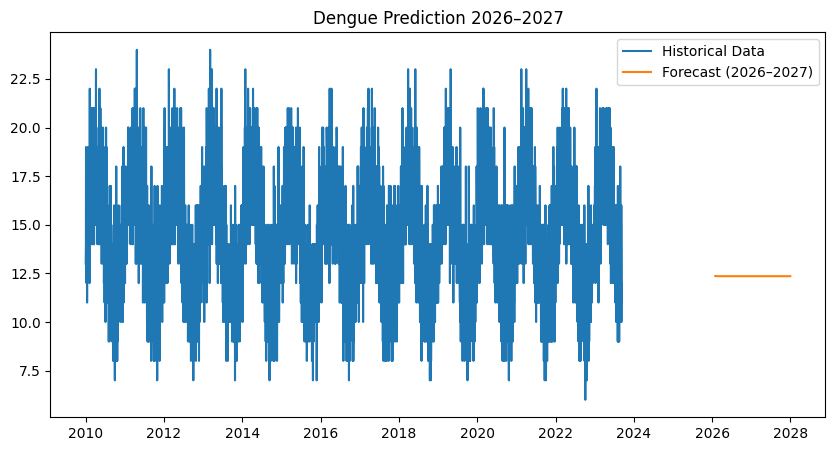

In [21]:
plt.figure(figsize=(10,5))

plt.plot(data['Dengue_Cases'], label="Historical Data")
plt.plot(future_dates, forecast_series, label="Forecast (2026–2027)")

plt.legend()
plt.title("Dengue Prediction 2026–2027")

plt.show()

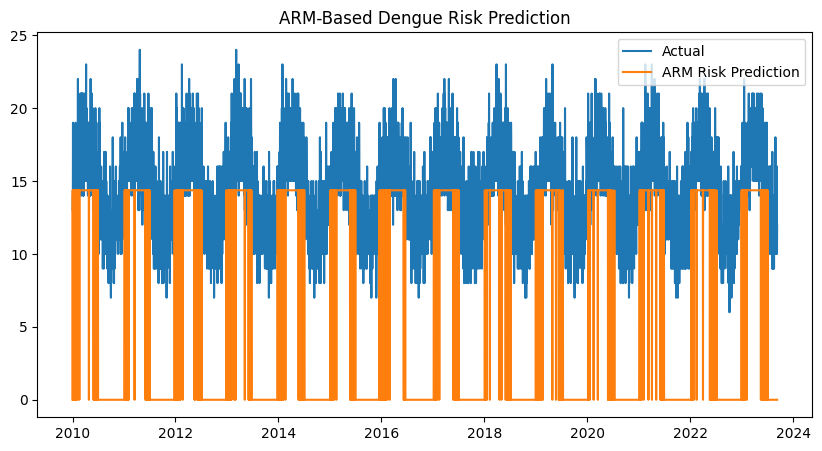

In [22]:
risk_prediction = arm_data['High_Temp'] & arm_data['High_Rain'] & arm_data['High_Humidity']

risk_prediction = risk_prediction.astype(int)

plt.figure(figsize=(10,5))

plt.plot(data.index, data['Dengue_Cases'], label="Actual")
plt.plot(data.index, risk_prediction * data['Dengue_Cases'].mean(), label="ARM Risk Prediction")

plt.legend()
plt.title("ARM-Based Dengue Risk Prediction")

plt.show()